### Parse flowmonitor to have histograms of packet size, delay and jitter to confirm traffic distributions

Note: gives good stats for video traffic

https://www.datacamp.com/tutorial/python-xml-elementtree

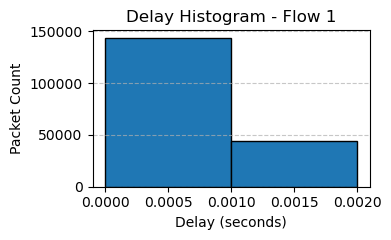

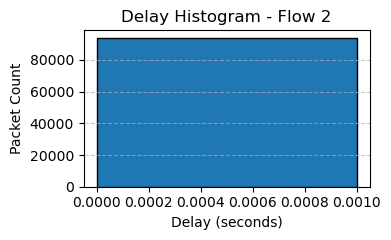

In [59]:
import xml.etree.ElementTree as ET
import matplotlib.pyplot as plt
from collections import defaultdict
import numpy as np
#------------flow delays
# Load XML
tree = ET.parse('ns-3-dev/multi-links-flow.xml')  # replace with your file path
root = tree.getroot()
# Dictionary to store delays for each flow
flow_delays = defaultdict(lambda: {"delays": [], "counts": []})
# Loop over each Flow element
for flow in root.findall(".//Flow"):
    flow_id = flow.attrib.get("flowId")
    
    delays = []
    counts = []
    
    # Extract this flow's delay histogram
    for bin_elem in flow.findall(".//delayHistogram/bin"):
        start = float(bin_elem.attrib["start"])
        count = int(bin_elem.attrib["count"])
        delays.append(start)
        counts.append(count)
    
    # Skip if no data
    if not delays:
        continue
    flow_delays[flow_id]["delays"] = delays
    flow_delays[flow_id]["counts"] = counts
    # Plot for this flow
    plt.figure(figsize=(4, 2.5))  # small figure
    plt.bar(delays, counts, width=0.001, align="edge", edgecolor="black")
    plt.xlabel("Delay (seconds)")
    plt.ylabel("Packet Count")
    plt.title(f"Delay Histogram - Flow {flow_id}")
    plt.grid(axis="y", linestyle="--", alpha=0.7)
    plt.tight_layout()
    plt.show()


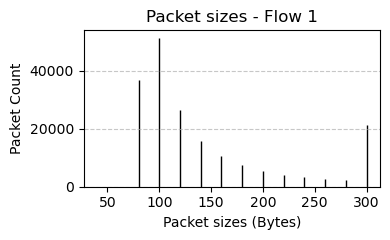

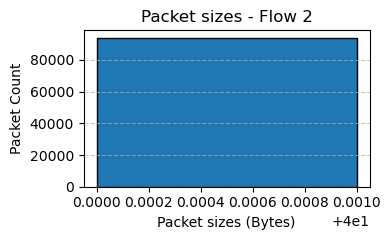

In [60]:
#------------flow packet size
# Load XML
tree = ET.parse('ns-3-dev/multi-links-flow.xml')  # replace with your file path
root = tree.getroot()
# Dictionary to store delays for each flow
flow_sizes = defaultdict(lambda: {"sizes": [], "counts": []})
# Loop over each Flow element
for flow in root.findall(".//Flow"):
    flow_id = flow.attrib.get("flowId")
    
    sizes = []
    counts = []
    
    # Extract this flow's delay histogram
    for bin_elem in flow.findall(".//packetSizeHistogram/bin"):
        start = float(bin_elem.attrib["start"])
        count = int(bin_elem.attrib["count"])
        sizes.append(start)
        counts.append(count)
    
    # Skip if no data
    if not sizes:
        continue
    flow_sizes[flow_id]["sizes"] = sizes
    flow_sizes[flow_id]["counts"] = counts
    # Plot for this flow
    plt.figure(figsize=(4, 2.5))  # small figure
    plt.bar(sizes, counts, width=0.001, align="edge", edgecolor="black")
    plt.xlabel("Packet sizes (Bytes)")
    plt.ylabel("Packet Count")
    plt.title(f"Packet sizes - Flow {flow_id}")
    plt.grid(axis="y", linestyle="--", alpha=0.7)
    plt.tight_layout()
    plt.show()


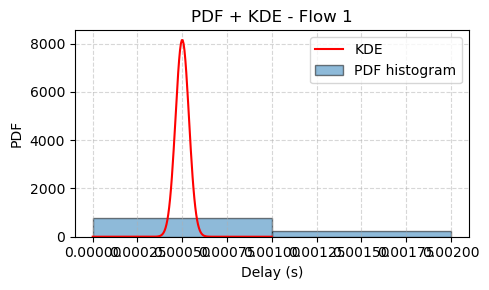

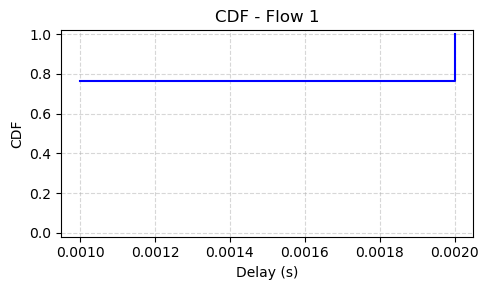

In [61]:

from scipy.stats import gaussian_kde

def plot_hist_kde_cdf(delays, counts, xlabel,flow_id=None):
    # Convert to numpy arrays
    delays = np.array(delays, dtype=float)
    counts = np.array(counts, dtype=float)
    
    # Infer bin width
    if len(delays) > 1:
        bin_width = np.diff(delays).mean()
    else:
        bin_width = 1.0  # fallback
    
    # Normalize counts to get PDF heights
    total_count = counts.sum()
    prob_mass = counts / total_count
    pdf_heights = prob_mass / bin_width  # density
    
    # Prepare bin centers for KDE and plotting
    bin_centers = delays + bin_width / 2
    
    # 1) Histogram (PDF)
    plt.figure(figsize=(5, 3))
    plt.bar(bin_centers, pdf_heights, width=bin_width, alpha=0.5, edgecolor="black", label="PDF histogram")
    
    # 2) KDE from bin centers (weighted by counts)
    kde = gaussian_kde(np.repeat(bin_centers, counts.astype(int)))
    x_grid = np.linspace(delays.min(), delays.max(), 200)
    plt.plot(x_grid, kde(x_grid), color="red", label="KDE")
    
    plt.xlabel(xlabel)
    plt.ylabel("PDF")
    plt.title(f"PDF + KDE - Flow {flow_id}" if flow_id else "PDF + KDE")
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.legend()
    plt.tight_layout()
    plt.show()
    
    # 3) CDF from histogram
    cdf = np.cumsum(prob_mass)
    right_edges = delays + bin_width
    plt.figure(figsize=(5, 3))
    plt.step(right_edges, cdf, where="post", color="blue")
    plt.xlabel(xlabel)
    plt.ylabel("CDF")
    plt.title(f"CDF - Flow {flow_id}" if flow_id else "CDF")
    plt.ylim(-0.02, 1.02)
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.tight_layout()
    plt.show()

# Example usage with one flow
fid = "1"
plot_hist_kde_cdf(flow_delays[fid]["delays"], flow_delays[fid]["counts"], "Delay (s)",flow_id=fid)


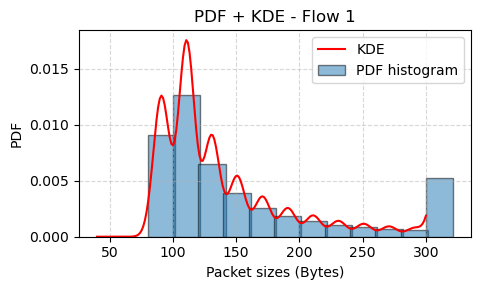

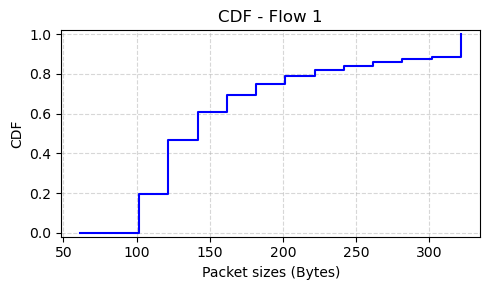

In [62]:
# Example usage with one flow
fid = "1"
plot_hist_kde_cdf(flow_sizes[fid]["sizes"], flow_sizes[fid]["counts"],"Packet sizes (Bytes)", flow_id=fid)

Packet arrival time

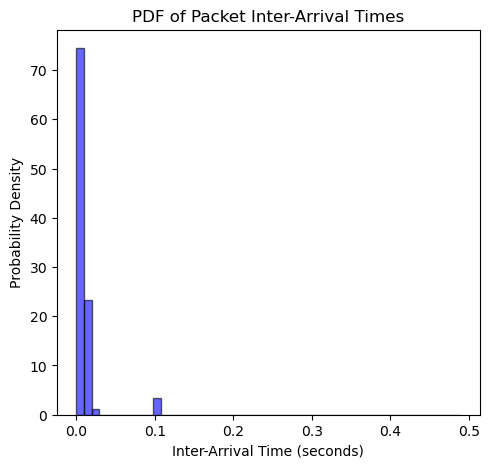

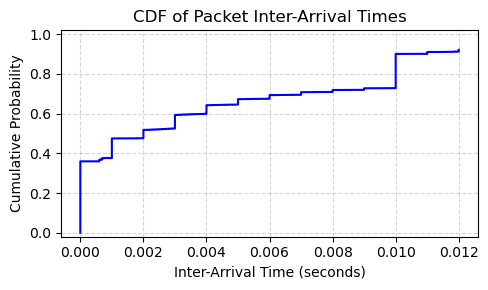

In [63]:
import numpy as np
import matplotlib.pyplot as plt

filename = 'ns-3-dev/packet_arrival_times.txt'
packet_times = np.loadtxt(filename)

inter_arrival_times = np.diff(packet_times)

plt.figure(figsize=(12, 5))


plt.subplot(1, 2, 1)
count, bins, ignored = plt.hist(inter_arrival_times, bins=50, density=True, alpha=0.6, color='blue', edgecolor='black')
plt.title('PDF of Packet Inter-Arrival Times')
plt.xlabel('Inter-Arrival Time (seconds)')
plt.ylabel('Probability Density')

plt.figure(figsize=(5, 3))
sorted_data = np.sort(inter_arrival_times)
cdf = np.arange(1, len(sorted_data) + 1) / len(sorted_data)

plt.step(sorted_data[:260000], cdf[:260000], where="post", color="blue")
plt.title('CDF of Packet Inter-Arrival Times')
plt.xlabel('Inter-Arrival Time (seconds)')
plt.ylabel('Cumulative Probability')

plt.ylim(-0.02, 1.02)
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


In [64]:
len(sorted_data)

282082

In [65]:
sorted_data[260000]

np.float64(0.012000000000000455)

In [66]:
#frame_start_times = packet_times[::8]  # every 8th packet is start of a frame
#inter_frame_times = np.diff(frame_start_times)